In [3]:
!pip install kaggle

In [4]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
# API to fetch the dataset from Kaggle
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
face-mask-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [6]:
# extracting the compessed Dataset
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

In [8]:
with_mask_files = os.listdir('/content/data/with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_2720.jpg', 'with_mask_727.jpg', 'with_mask_2630.jpg', 'with_mask_2719.jpg', 'with_mask_3192.jpg']
['with_mask_3010.jpg', 'with_mask_2291.jpg', 'with_mask_2248.jpg', 'with_mask_666.jpg', 'with_mask_1112.jpg']


In [9]:
without_mask_files = os.listdir('/content/data/without_mask')
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_3246.jpg', 'without_mask_2401.jpg', 'without_mask_3368.jpg', 'without_mask_1808.jpg', 'without_mask_3137.jpg']
['without_mask_2605.jpg', 'without_mask_3821.jpg', 'without_mask_2091.jpg', 'without_mask_3287.jpg', 'without_mask_2906.jpg']


In [10]:
print('Number of with mask images:', len(with_mask_files))
print('Number of without mask images:', len(without_mask_files))

Number of with mask images: 3725
Number of without mask images: 3828


Creating Labels for the two class of Images

with mask --> 1

without mask --> 0

In [11]:
# create the labels

with_mask_labels = [1]*3725

without_mask_labels = [0]*3828

print(with_mask_labels[0:5])

print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [12]:
labels = with_mask_labels + without_mask_labels

print(len(labels))


7553


## Converting the images to numpy arrays

In [13]:
# convert images to numpy arrays+

with_mask_path = '/content/data/with_mask/'

data = []

for img_file in with_mask_files:

  image = Image.open(with_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)



without_mask_path = '/content/data/without_mask/'


for img_file in without_mask_files:

  image = Image.open(without_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


array([[[ 17,  82, 112],
        [ 18,  83, 113],
        [ 19,  84, 114],
        ...,
        [ 13,  78, 108],
        [ 14,  78, 106],
        [ 16,  78, 103]],

       [[ 18,  83, 113],
        [ 18,  83, 113],
        [ 19,  84, 114],
        ...,
        [ 14,  79, 109],
        [ 13,  78, 106],
        [ 15,  78, 104]],

       [[ 18,  83, 114],
        [ 19,  84, 114],
        [ 20,  85, 115],
        ...,
        [ 14,  79, 109],
        [ 14,  79, 107],
        [ 15,  79, 106]],

       ...,

       [[ 51, 116, 154],
        [ 51, 116, 154],
        [ 51, 116, 154],
        ...,
        [ 50, 115, 153],
        [ 48, 114, 152],
        [ 46, 114, 151]],

       [[ 51, 116, 154],
        [ 51, 116, 154],
        [ 51, 116, 154],
        ...,
        [ 49, 114, 152],
        [ 47, 114, 151],
        [ 45, 113, 150]],

       [[ 50, 115, 153],
        [ 50, 115, 153],
        [ 50, 115, 153],
        ...,
        [ 48, 113, 151],
        [ 47, 113, 151],
        [ 45, 113, 150]]], dtype=uint8)
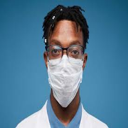

In [14]:
data[0]

In [15]:
data[0].shape

(128, 128, 3)

In [16]:
# converting image list and label list to numpy arrays

X = np.array(data)
Y = np.array(labels)

In [17]:
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


## Train Test Split

In [18]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print(X.shape, X_train.shape, X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [19]:
# scaling the data
X_train_scaled = X_train/255
X_test_scaled = X_test/255

In [20]:
X_train_scaled[0]

array([[[0.18823529, 0.19607843, 0.24705882],
        [0.18823529, 0.19607843, 0.24313725],
        [0.18039216, 0.18431373, 0.22352941],
        ...,
        [0.19215686, 0.18431373, 0.22745098],
        [0.21568627, 0.20784314, 0.25098039],
        [0.23137255, 0.22352941, 0.26666667]],

       [[0.17647059, 0.18431373, 0.23529412],
        [0.17647059, 0.18431373, 0.23137255],
        [0.18431373, 0.18431373, 0.22352941],
        ...,
        [0.19215686, 0.18039216, 0.22745098],
        [0.2       , 0.19215686, 0.23137255],
        [0.24313725, 0.23529412, 0.27058824]],

       [[0.17254902, 0.18431373, 0.22352941],
        [0.16862745, 0.18039216, 0.21568627],
        [0.18431373, 0.18431373, 0.21960784],
        ...,
        [0.19215686, 0.18823529, 0.21960784],
        [0.2       , 0.19607843, 0.22352941],
        [0.21960784, 0.21568627, 0.24313725]],

       ...,

       [[0.8627451 , 0.8627451 , 0.81960784],
        [0.87058824, 0.8745098 , 0.82745098],
        [0.8627451 , 0

# Building a Convolutional Neural Networks (CNN)

In [21]:
import tensorflow as tf
from tensorflow import keras

In [22]:
num_of_classes = 2

model = keras.Sequential()

model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))


model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(num_of_classes, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
# compile the neural network
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

In [24]:
# training the neural network
history = model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=5)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - acc: 0.6712 - loss: 0.7389 - val_acc: 0.8777 - val_loss: 0.3066
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - acc: 0.8708 - loss: 0.3319 - val_acc: 0.9025 - val_loss: 0.2715
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - acc: 0.9085 - loss: 0.2206 - val_acc: 0.9091 - val_loss: 0.2425
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - acc: 0.9203 - loss: 0.1995 - val_acc: 0.9190 - val_loss: 0.2305
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - acc: 0.9390 - loss: 0.1657 - val_acc: 0.9157 - val_loss: 0.2470


In [25]:
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print('Test Accuracy =', accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - acc: 0.9280 - loss: 0.2058
Test Accuracy = 0.9278623461723328


### Model Save

In [ ]:
model.save('model.h5')
from google.colab import files
files.download('mask_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Model performance

In [27]:
def plot_accuracy_and_loss(history):
    plt.figure(figsize=(12, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['acc'], label='Train Accuracy')
    plt.plot(history.history['val_acc'], label='Validation Accuracy')
    plt.title('Model Accuracy per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


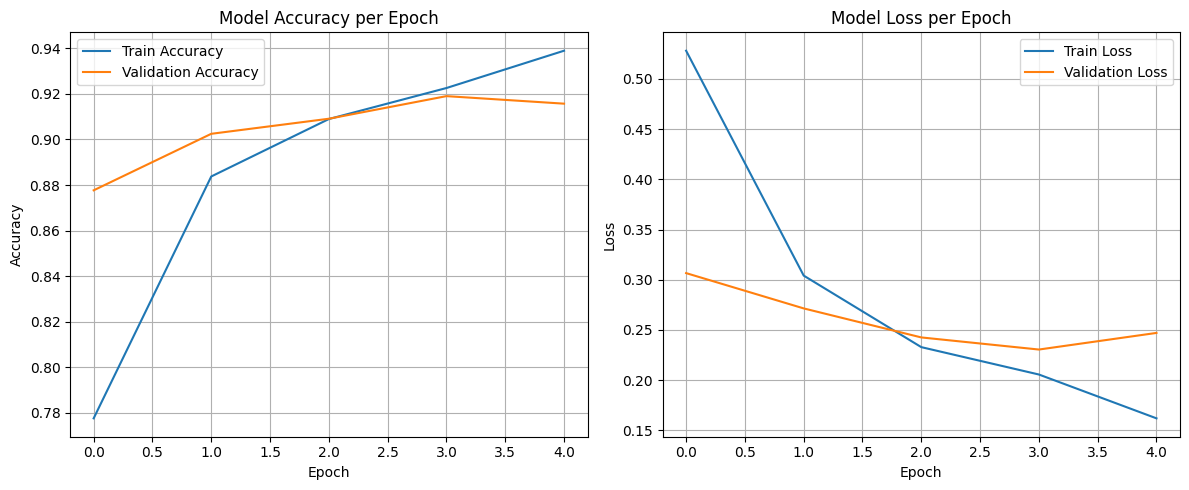

In [31]:
plot_accuracy_and_loss(history)

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


y_pred_probs = model.predict(X_test_scaled)
y_pred_classes = y_pred_probs.argmax(axis=1)  # choose class with highest prob


accuracy = accuracy_score(Y_test, y_pred_classes)
precision = precision_score(Y_test, y_pred_classes, average='binary')
recall = recall_score(Y_test, y_pred_classes, average='binary')
f1 = f1_score(Y_test, y_pred_classes, average='binary')

print(f" Accuracy: {accuracy*100:.2f}%")
print(f" Precision: {precision*100:.2f}%")
print(f" Recall: {recall*100:.2f}%")
print(f" F1 Score: {f1*100:.2f}%")





48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
 Accuracy: 92.79%
 Precision: 93.70%
 Recall: 91.85%
 F1 Score: 92.77%
